In [1]:
# Import all tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# See first 5 rows
df.head()

# Check shape — how many rows and columns
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 7043 rows and 21 columns


In [4]:
# Fix TotalCharges — it's text, should be number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove empty rows
df.dropna(inplace=True)

# Remove CustomerID — not useful for prediction
df.drop('customerID', axis=1, inplace=True)

# Convert Yes/No columns to 1/0 (ML needs numbers)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert all other text columns to numbers
df = pd.get_dummies(df, drop_first=True)

print("Data cleaned! Shape now:", df.shape)

Data cleaned! Shape now: (7032, 31)


In [5]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)  # everything except churn
y = df['Churn']               # what we want to predict

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 78.54%

Detailed Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



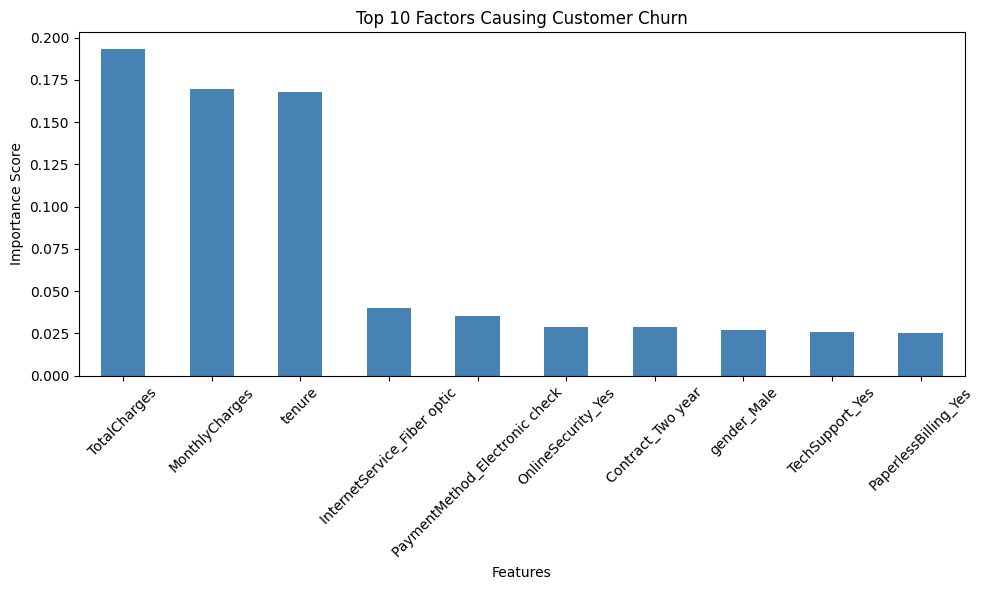

Top 5 reasons customers churn:
TotalCharges                      0.193409
MonthlyCharges                    0.169758
tenure                            0.167572
InternetService_Fiber optic       0.039999
PaymentMethod_Electronic check    0.035016
dtype: float64


In [6]:
# Get feature importance scores
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
importance[:10].plot(kind='bar', color='steelblue')
plt.title('Top 10 Factors Causing Customer Churn')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print top 5 reasons for churn
print("Top 5 reasons customers churn:")
print(importance[:5])